# PINN para el problema de Boussinesq (carga puntual sobre un semiespacio elástico)

## Diagnóstico del código original y qué se cambió

| # | Problema en la versión original | Corrección |
|---|---|---|
| 1 | **Se regularizaba la carga puntual con una gaussiana** (`sigma_load` decreciente) y se evitaba el origen (`r ≥ 0.1`). La red nunca veía la singularidad y el problema resuelto era otro. | Se impone la carga **exacta** mediante el equilibrio vertical de hemisferios de radio ρ₀: ∫ t_z dA = −P. Es la forma débil correcta de una fuerza puntual, sin gaussiana ni `sigma_load`. |
| 2 | La red aproximaba directamente desplazamientos con una MLP suave, pero la solución real es **u ∝ 1/ρ** y **σ ∝ 1/ρ²**: una MLP no puede representar eso cerca del origen. | *Ansatz* con la singularidad incorporada: `u_r = r·q`, `q = k₀·A/ρ²`, `w = k₀·B/ρ`, con `A, B` = salidas suaves O(1) de la red. La red solo aprende la parte angular. |
| 3 | El residuo de la EDP pesaba igual todos los puntos: cerca del origen explota (~1/ρ³) y domina la pérdida, mientras que el resto queda sin aprender. | El residuo se **adimensionaliza** (`ρ³·eq`, `ρ²·σ`), de modo que todas las escalas pesan igual. |
| 4 | Muestreo con 70 % de puntos en una gaussiana alrededor del origen, pero con `r ≥ 0.1`: la región crítica quedaba vacía. | Muestreo **uniforme en ln ρ** (de 10⁻⁵ a 15): cada década alrededor de la singularidad tiene el mismo peso. Ángulo θ refinado cerca de la superficie. |
| 5 | `eps_tt = u_r / r` y `(s_rr − s_tt)/r` divergen en el eje `r = 0`. | `u_r = r·q` ⇒ `ε_θθ = q` y `(σ_rr − σ_θθ)/r = 2G·∂q/∂r` **sin dividir por r**. Las entradas `(ln ρ, z/ρ)` hacen los campos pares en r ⇒ suaves en el eje. |
| 6 | La condición de campo lejano forzaba tensión cero en la frontera truncada (r = 10, z = 10), donde la solución **no** es cero. Introducía un error sistemático. | Se elimina. La unicidad la dan la superficie libre, el equilibrio de fuerzas y el decaimiento impuesto por el *ansatz*. |
| 7 | Solo Adam con α fijo, 3000 épocas, `float32`; comentario "Tanh" pero usaba SiLU. | `float64`, `tanh`, Adam + coseno y después **L-BFGS** (líneas de búsqueda strong-Wolfe) sobre muestras grandes. |
| 8 | El "early stopping" solo se comprobaba cada 500 épocas y `r.requires_grad = True` modificaba los tensores de entrada. | Se usan copias con `requires_grad_` y el criterio de parada es la fase L-BFGS. |

**Nota sobre `USE_S`.** El problema de Boussinesq es autosemejante: no hay ninguna longitud en el enunciado (semiespacio infinito, carga puntual), y la única construible con los datos, √(P/E), queda descartada por la **linealidad** (metería a P dentro de una raíz y rompería u ∝ P). Como ρ es entonces la única longitud disponible, u·E·ρ/P solo puede depender del ángulo θ. Con `USE_S = False` la red recibe solo `cos θ = z/ρ` y esa propiedad queda impuesta; con `USE_S = True` la red recibe también `ln ρ` y tiene que *descubrir* la autosemejanza (más general, pero más lento y menos preciso).

In [1]:
import math, time
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)          # precisión doble: imprescindible para L-BFGS y derivadas de 2.º orden
torch.manual_seed(0); np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

TWO_PI = 2.0 * math.pi

def grad(f, x):
    return torch.autograd.grad(f, x, torch.ones_like(f), create_graph=True, retain_graph=True)[0]

Dispositivo: cpu


## 1. Red neuronal con la singularidad incorporada

Con coordenadas esféricas ρ = √(r²+z²), c = z/ρ = cos θ:

$$u_r = r\,q,\qquad q=\frac{k_0\,A(s,c)}{\rho^{2}},\qquad w=\frac{k_0\,B(s,c)}{\rho},\qquad s=\ln\rho,\ k_0=\frac1{2\pi}$$

`A` y `B` son O(1) y suaves; todo el comportamiento singular (u ~ 1/ρ, σ ~ 1/ρ²) está en los factores explícitos.

In [2]:
class SingularPINN(nn.Module):
    """Devuelve A(s,c), B(s,c): campos suaves O(1). La singularidad 1/rho se añade fuera de la red."""

    def __init__(self, hidden=32, depth=4, rho_min=1e-5, rho_max=15.0, use_s=False):
        super().__init__()
        self.use_s = use_s
        self.s_mid  = 0.5 * (math.log(rho_min) + math.log(rho_max))
        self.s_half = 0.5 * (math.log(rho_max) - math.log(rho_min))
        n_in = 2 if use_s else 1
        dims = [n_in] + [hidden] * depth + [2]
        self.lin = nn.ModuleList([nn.Linear(dims[i], dims[i + 1]) for i in range(len(dims) - 1)])
        for l in self.lin:
            nn.init.xavier_normal_(l.weight)
            nn.init.zeros_(l.bias)

    def AB(self, s, c):
        x = 2.0 * c - 1.0                                   # c in [0,1] -> [-1,1]
        if self.use_s:
            x = torch.cat([(s - self.s_mid) / self.s_half, x], dim=1)
        for l in self.lin[:-1]:
            x = torch.tanh(l(x))
        o = self.lin[-1](x)
        return o[:, 0:1], o[:, 1:2]

## 2. Física: equilibrio, superficie libre y carga puntual exacta

* **Equilibrio** axisimétrico (residuos adimensionales `2π ρ³ · eq`).
* **Superficie libre** (z = 0, r > 0): σ_zz = τ_rz = 0 (residuo `2π r² σ`).
* **Carga puntual**: para cualquier hemisferio de radio ρ₀, ∫₀^{π/2} (σ_zz cos θ + τ_rz sin θ)·2πρ₀² sin θ dθ = −P (cuadratura de Gauss-Legendre). Reemplaza a la gaussiana.

Internamente se trabaja con P = E = 1 (problema lineal) y al final se reescala por `P` y `P/E`.

In [3]:
class BoussinesqPINN:
    def __init__(self, net, nu=0.3, E=1.0, P=100.0, rho_min=1e-5, rho_max=15.0, n_quad=32):
        self.net = net.to(device)
        self.nu, self.E, self.P = nu, E, P
        self.rho_min, self.rho_max = rho_min, rho_max
        self.k0 = 1.0 / TWO_PI
        xg, wg = np.polynomial.legendre.leggauss(n_quad)             # cuadratura en theta in [0, pi/2]
        self.th_q = torch.tensor(0.25 * math.pi * (xg + 1.0), device=device).reshape(-1, 1)
        self.w_q  = torch.tensor(0.25 * math.pi * wg,         device=device).reshape(-1, 1)
        self.hist = {k: [] for k in ["total", "pde", "sig", "tau", "force"]}

    # ---- campos de desplazamiento: q = u_r/r  y  w  (adimensionales) ------------------------
    def fields(self, r, z):
        rho = torch.sqrt(r ** 2 + z ** 2)
        A, B = self.net.AB(torch.log(rho), z / rho)
        return self.k0 * A / rho ** 2, self.k0 * B / rho, rho

    def stresses_nd(self, r, z):
        """Tensiones en unidades de P (independientes de E). Sin divisiones por r."""
        q, ww, _ = self.fields(r, z)
        q_r, q_z = grad(q, r), grad(q, z)
        w_r, w_z = grad(ww, r), grad(ww, z)
        nu  = self.nu
        e_tt, e_rr, e_zz = q, q + r * q_r, w_z
        g_rz = r * q_z + w_r
        lam = nu / ((1 + nu) * (1 - 2 * nu)); G = 1.0 / (2 * (1 + nu))
        tr = e_rr + e_tt + e_zz
        s_rr, s_tt, s_zz = 2 * G * e_rr + lam * tr, 2 * G * e_tt + lam * tr, 2 * G * e_zz + lam * tr
        return s_zz, s_rr, s_tt, G * g_rz, q_r, G

    # ---- API física (misma firma que el notebook original) ----------------------------------
    def get_stresses(self, r, z):
        r = r.clone().requires_grad_(True); z = z.clone().requires_grad_(True)
        s_zz, s_rr, s_tt, t_rz, _, _ = self.stresses_nd(r, z)
        return self.P * s_zz, self.P * s_rr, self.P * s_tt, self.P * t_rz

    def displacements(self, r, z):
        with torch.no_grad():
            q, ww, _ = self.fields(r, z)
        return self.P / self.E * r * q, self.P / self.E * ww

    # ---- residuos -----------------------------------------------------------------------------
    def pde_residual(self, rho, th):
        r = (rho * torch.sin(th)).requires_grad_(True)
        z = (rho * torch.cos(th)).requires_grad_(True)
        s_zz, s_rr, s_tt, t_rz, q_r, G = self.stresses_nd(r, z)
        eq1 = grad(s_rr, r) + grad(t_rz, z) + 2 * G * q_r       # (s_rr - s_tt)/r = 2G dq/dr  (exacto)
        eq2 = grad(t_rz, r) + grad(s_zz, z) + t_rz / r
        rho_ = torch.sqrt(r ** 2 + z ** 2)
        return TWO_PI * rho_ ** 3 * eq1, TWO_PI * rho_ ** 3 * eq2   # invariante de escala

    def surface_residual(self, rho):
        r = rho.clone().requires_grad_(True); z = torch.zeros_like(rho).requires_grad_(True)
        s_zz, _, _, t_rz, _, _ = self.stresses_nd(r, z)
        return TWO_PI * r ** 2 * s_zz, TWO_PI * r ** 2 * t_rz

    def force_residual(self, rho0):
        """Equilibrio vertical de hemisferios de radio rho0: F + P = 0 (con P = 1)."""
        n_r, n_q = rho0.shape[0], self.th_q.shape[0]
        th = self.th_q.T.expand(n_r, n_q).reshape(-1, 1)
        rr = rho0.reshape(-1, 1).expand(n_r, n_q).reshape(-1, 1)
        r = (rr * torch.sin(th)).requires_grad_(True); z = (rr * torch.cos(th)).requires_grad_(True)
        s_zz, _, _, t_rz, _, _ = self.stresses_nd(r, z)
        integrand = (s_zz * torch.cos(th) + t_rz * torch.sin(th)) * TWO_PI * rr ** 2 * torch.sin(th)
        w = self.w_q.T.expand(n_r, n_q).reshape(-1, 1)
        return (integrand * w).reshape(n_r, n_q).sum(dim=1) + 1.0

    # ---- muestreo: uniforme en ln(rho) => misma importancia en cada década alrededor del origen ----
    def sample(self, n_pde, n_bc, n_rad):
        lo, hi = math.log(self.rho_min), math.log(self.rho_max)
        logu = lambda n: torch.exp(lo + (hi - lo) * torch.rand(n, 1, device=device))
        rho = logu(n_pde)
        u = torch.rand(n_pde, 1, device=device)
        th_max = 0.5 * math.pi - 1e-3
        th = torch.where(torch.rand(n_pde, 1, device=device) < 0.7,
                         u * th_max + 1e-3,                  # uniforme
                         (1 - u ** 2) * th_max + 1e-3)       # refinado hacia la superficie (theta -> pi/2)
        return rho, th, logu(n_bc), logu(n_rad)

    def loss(self, pts, w):
        rho, th, rho_s, rho_f = pts
        e1, e2 = self.pde_residual(rho, th)
        l_pde = torch.mean(e1 ** 2) + torch.mean(e2 ** 2)
        s_zz, t_rz = self.surface_residual(rho_s)
        l_sig, l_tau = torch.mean(s_zz ** 2), torch.mean(t_rz ** 2)
        l_F = torch.mean(self.force_residual(rho_f) ** 2)
        tot = w["pde"] * l_pde + w["bc"] * (l_sig + l_tau) + w["force"] * l_F
        return tot, l_pde, l_sig, l_tau, l_F

    def _log(self, vals):
        for k, v in zip(self.hist, vals):
            self.hist[k].append(v.item())

    def train(self, adam_epochs=1500, n_pde=600, n_bc=40, n_rad=4, lr=2e-3, lbfgs_iters=800,
              lbfgs_rounds=4, resample_every=50, w=None, verbose=250):
        w = w or dict(pde=1.0, bc=1.0, force=1.0)
        opt = torch.optim.Adam(self.net.parameters(), lr=lr)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=adam_epochs, eta_min=1e-5)
        t0 = time.time()
        for ep in range(adam_epochs):                                  # fase 1: Adam (exploración)
            if ep % resample_every == 0:
                pts = self.sample(n_pde, n_bc, n_rad)
            opt.zero_grad(); out = self.loss(pts, w); out[0].backward(); opt.step(); sch.step()
            self._log(out)
            if ep % verbose == 0:
                print(f"Adam {ep:5d} | tot {out[0].item():.3e}  pde {out[1].item():.3e}  sig {out[2].item():.3e}  "
                      f"tau {out[3].item():.3e}  F {out[4].item():.3e} | {time.time()-t0:.0f}s", flush=True)
        for rd in range(lbfgs_rounds):                                 # fase 2: L-BFGS (afinado de alta precisión)
            pts = self.sample(2 * n_pde, 2 * n_bc, 2 * n_rad)
            lb = torch.optim.LBFGS(self.net.parameters(), lr=1.0, max_iter=lbfgs_iters,
                                   max_eval=int(1.25 * lbfgs_iters), history_size=50,
                                   tolerance_grad=1e-14, tolerance_change=1e-16, line_search_fn="strong_wolfe")
            def closure():
                lb.zero_grad(); out = self.loss(pts, w); out[0].backward(); self._last = out
                return out[0]
            lb.step(closure); self._log(self._last); o = self._last
            print(f"L-BFGS {rd+1}/{lbfgs_rounds} | tot {o[0].item():.3e}  pde {o[1].item():.3e}  sig {o[2].item():.3e}  "
                  f"tau {o[3].item():.3e}  F {o[4].item():.3e} | {time.time()-t0:.0f}s", flush=True)

## 3. Solución analítica de Boussinesq (referencia)

In [4]:
def analytic(r, z, P, nu, E=1.0):
    """Boussinesq: z hacia abajo, compresión negativa."""
    rho = np.sqrt(r ** 2 + z ** 2); k = P / (2 * np.pi); kk = P * (1 + nu) / (2 * np.pi * E)
    return dict(
        s_zz = -3 * k * z ** 3 / rho ** 5,
        t_rz = -3 * k * r * z ** 2 / rho ** 5,
        s_rr =  k * ((1 - 2 * nu) / (rho * (rho + z)) - 3 * r ** 2 * z / rho ** 5),
        s_tt =  k * (1 - 2 * nu) * (z / rho ** 3 - 1 / (rho * (rho + z))),
        u_r  =  kk * (r * z / rho ** 3 - (1 - 2 * nu) * r / (rho * (rho + z))),
        w    =  kk * (z ** 2 / rho ** 3 + 2 * (1 - nu) / rho))

## 4. Entrenamiento

In [5]:
# ---------------- Parámetros ----------------
R_DOMAIN, Z_DOMAIN = 10.0, 10.0
NU, E_MOD, P_LOAD  = 0.3, 1.0, 100.0
RHO_MIN, RHO_MAX   = 1e-5, 15.0            # la red ve la singularidad hasta rho = 1e-5 (> 5 décadas)

USE_S = False   # False: autosemejanza impuesta por análisis dimensional (más preciso y rápido)
                # True : la red recibe ln(rho) y debe descubrirla (usar hidden=40+, más iteraciones)

net    = SingularPINN(hidden=32, depth=4, rho_min=RHO_MIN, rho_max=RHO_MAX, use_s=USE_S)
solver = BoussinesqPINN(net, nu=NU, E=E_MOD, P=P_LOAD, rho_min=RHO_MIN, rho_max=RHO_MAX)
print("Parámetros entrenables:", sum(p.numel() for p in net.parameters()))

solver.train(adam_epochs=1500, n_pde=600, n_bc=40, n_rad=4, lbfgs_iters=800, lbfgs_rounds=4)

Parámetros entrenables: 3298


Adam     0 | tot 2.062e+00  pde 9.618e-01  sig 3.172e-01  tau 3.461e-02  F 7.482e-01 | 0s


Adam   250 | tot 4.650e-02  pde 2.984e-02  sig 2.692e-03  tau 7.165e-03  F 6.800e-03 | 17s


Adam   500 | tot 8.668e-03  pde 7.303e-03  sig 2.138e-05  tau 9.337e-04  F 4.101e-04 | 35s


Adam   750 | tot 1.791e-03  pde 1.589e-03  sig 3.905e-06  tau 1.237e-04  F 7.378e-05 | 52s


...

Adam  1250 | tot 9.806e-04  pde 9.462e-04  sig 1.104e-06  tau 2.023e-05  F 1.307e-05 | 86s


L-BFGS 1/4 | tot 1.170e-06  pde 1.170e-06  sig 3.218e-11  tau 1.665e-11  F 6.558e-12 | 210s


L-BFGS 2/4 | tot 1.162e-06  pde 1.162e-06  sig 1.566e-10  tau 7.463e-12  F 3.483e-12 | 319s


L-BFGS 3/4 | tot 1.036e-06  pde 1.035e-06  sig 4.831e-10  tau 2.079e-11  F 1.982e-11 | 422s


L-BFGS 4/4 | tot 1.030e-06  pde 1.029e-06  sig 2.370e-10  tau 3.483e-11  F 3.020e-11 | 524s


## 5. Curvas de aprendizaje y distribución de puntos

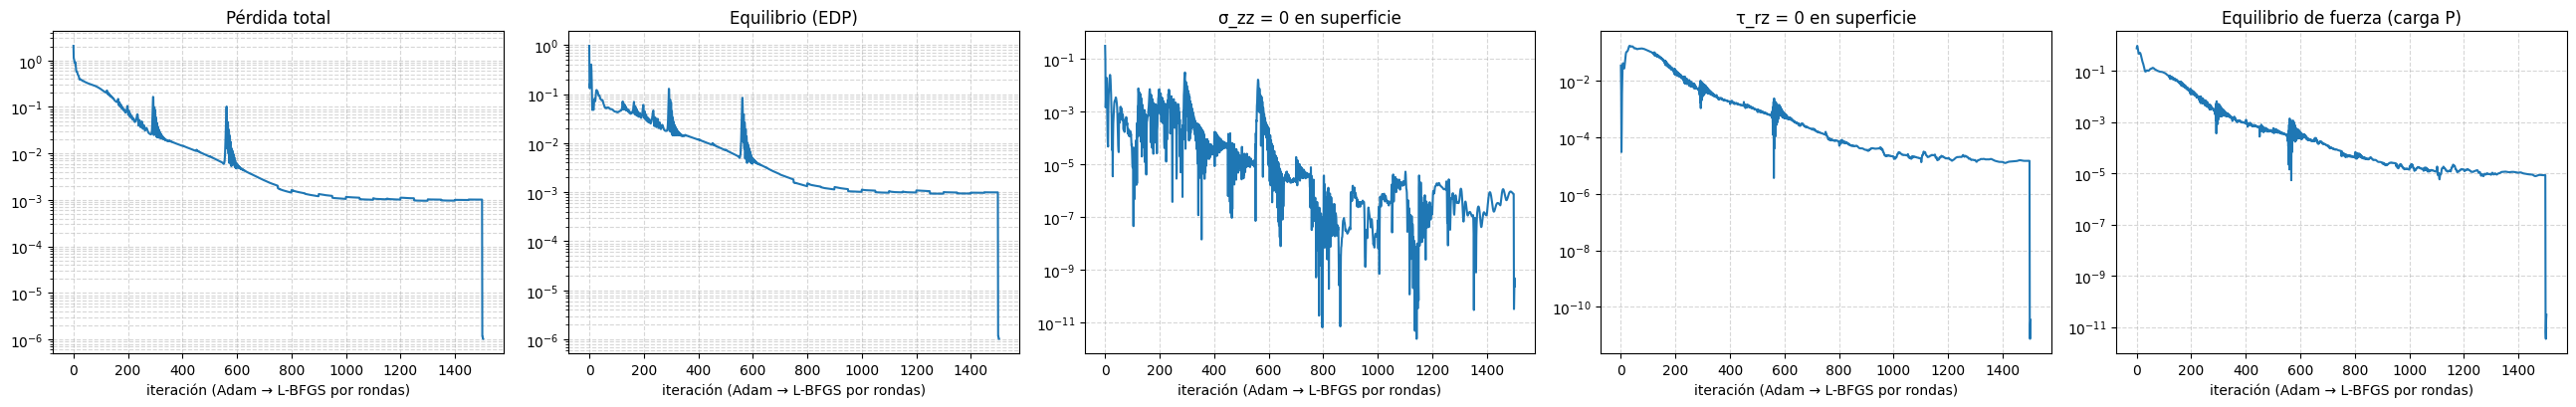

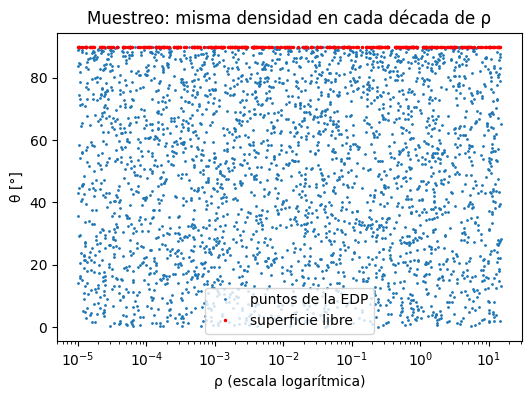

In [6]:
fig, ax = plt.subplots(1, 5, figsize=(26, 4.2))
for a, (k, t) in zip(ax, [("total", "Pérdida total"), ("pde", "Equilibrio (EDP)"), ("sig", "σ_zz = 0 en superficie"),
                          ("tau", "τ_rz = 0 en superficie"), ("force", "Equilibrio de fuerza (carga P)")]):
    a.semilogy(solver.hist[k]); a.set_title(t); a.set_xlabel("iteración (Adam → L-BFGS por rondas)"); a.grid(True, which="both", ls="--", alpha=.5)
plt.tight_layout(); plt.show()

rho_p, th_p, rho_s, rho_f = solver.sample(3000, 300, 30)
plt.figure(figsize=(6, 4))
plt.semilogx(rho_p.cpu(), th_p.cpu() * 180 / np.pi, ".", ms=2, label="puntos de la EDP")
plt.semilogx(rho_s.cpu(), np.full(len(rho_s), 90.0), "r.", ms=3, label="superficie libre")
plt.xlabel("ρ (escala logarítmica)"); plt.ylabel("θ [°]"); plt.title("Muestreo: misma densidad en cada década de ρ")
plt.legend(); plt.show()

## 6. Resultados frente a la solución analítica

El error se muestra normalizado con la escala local **P/(2πρ²)**, para que no quede oculto (ni magnificado) por la divergencia 1/ρ² en el origen.

 campo |  error L2 relativo |  error máx normalizado (local)
  σ_zz |          6.894e-06 |                      2.186e-04
  σ_rr |          1.845e-04 |                      1.835e-04
  σ_θθ |          5.658e-04 |                      9.361e-05
  τ_rz |          1.840e-05 |                      1.408e-04
   u_r |          9.082e-05 |                      1.117e-04
     w |          2.707e-05 |                      8.766e-05


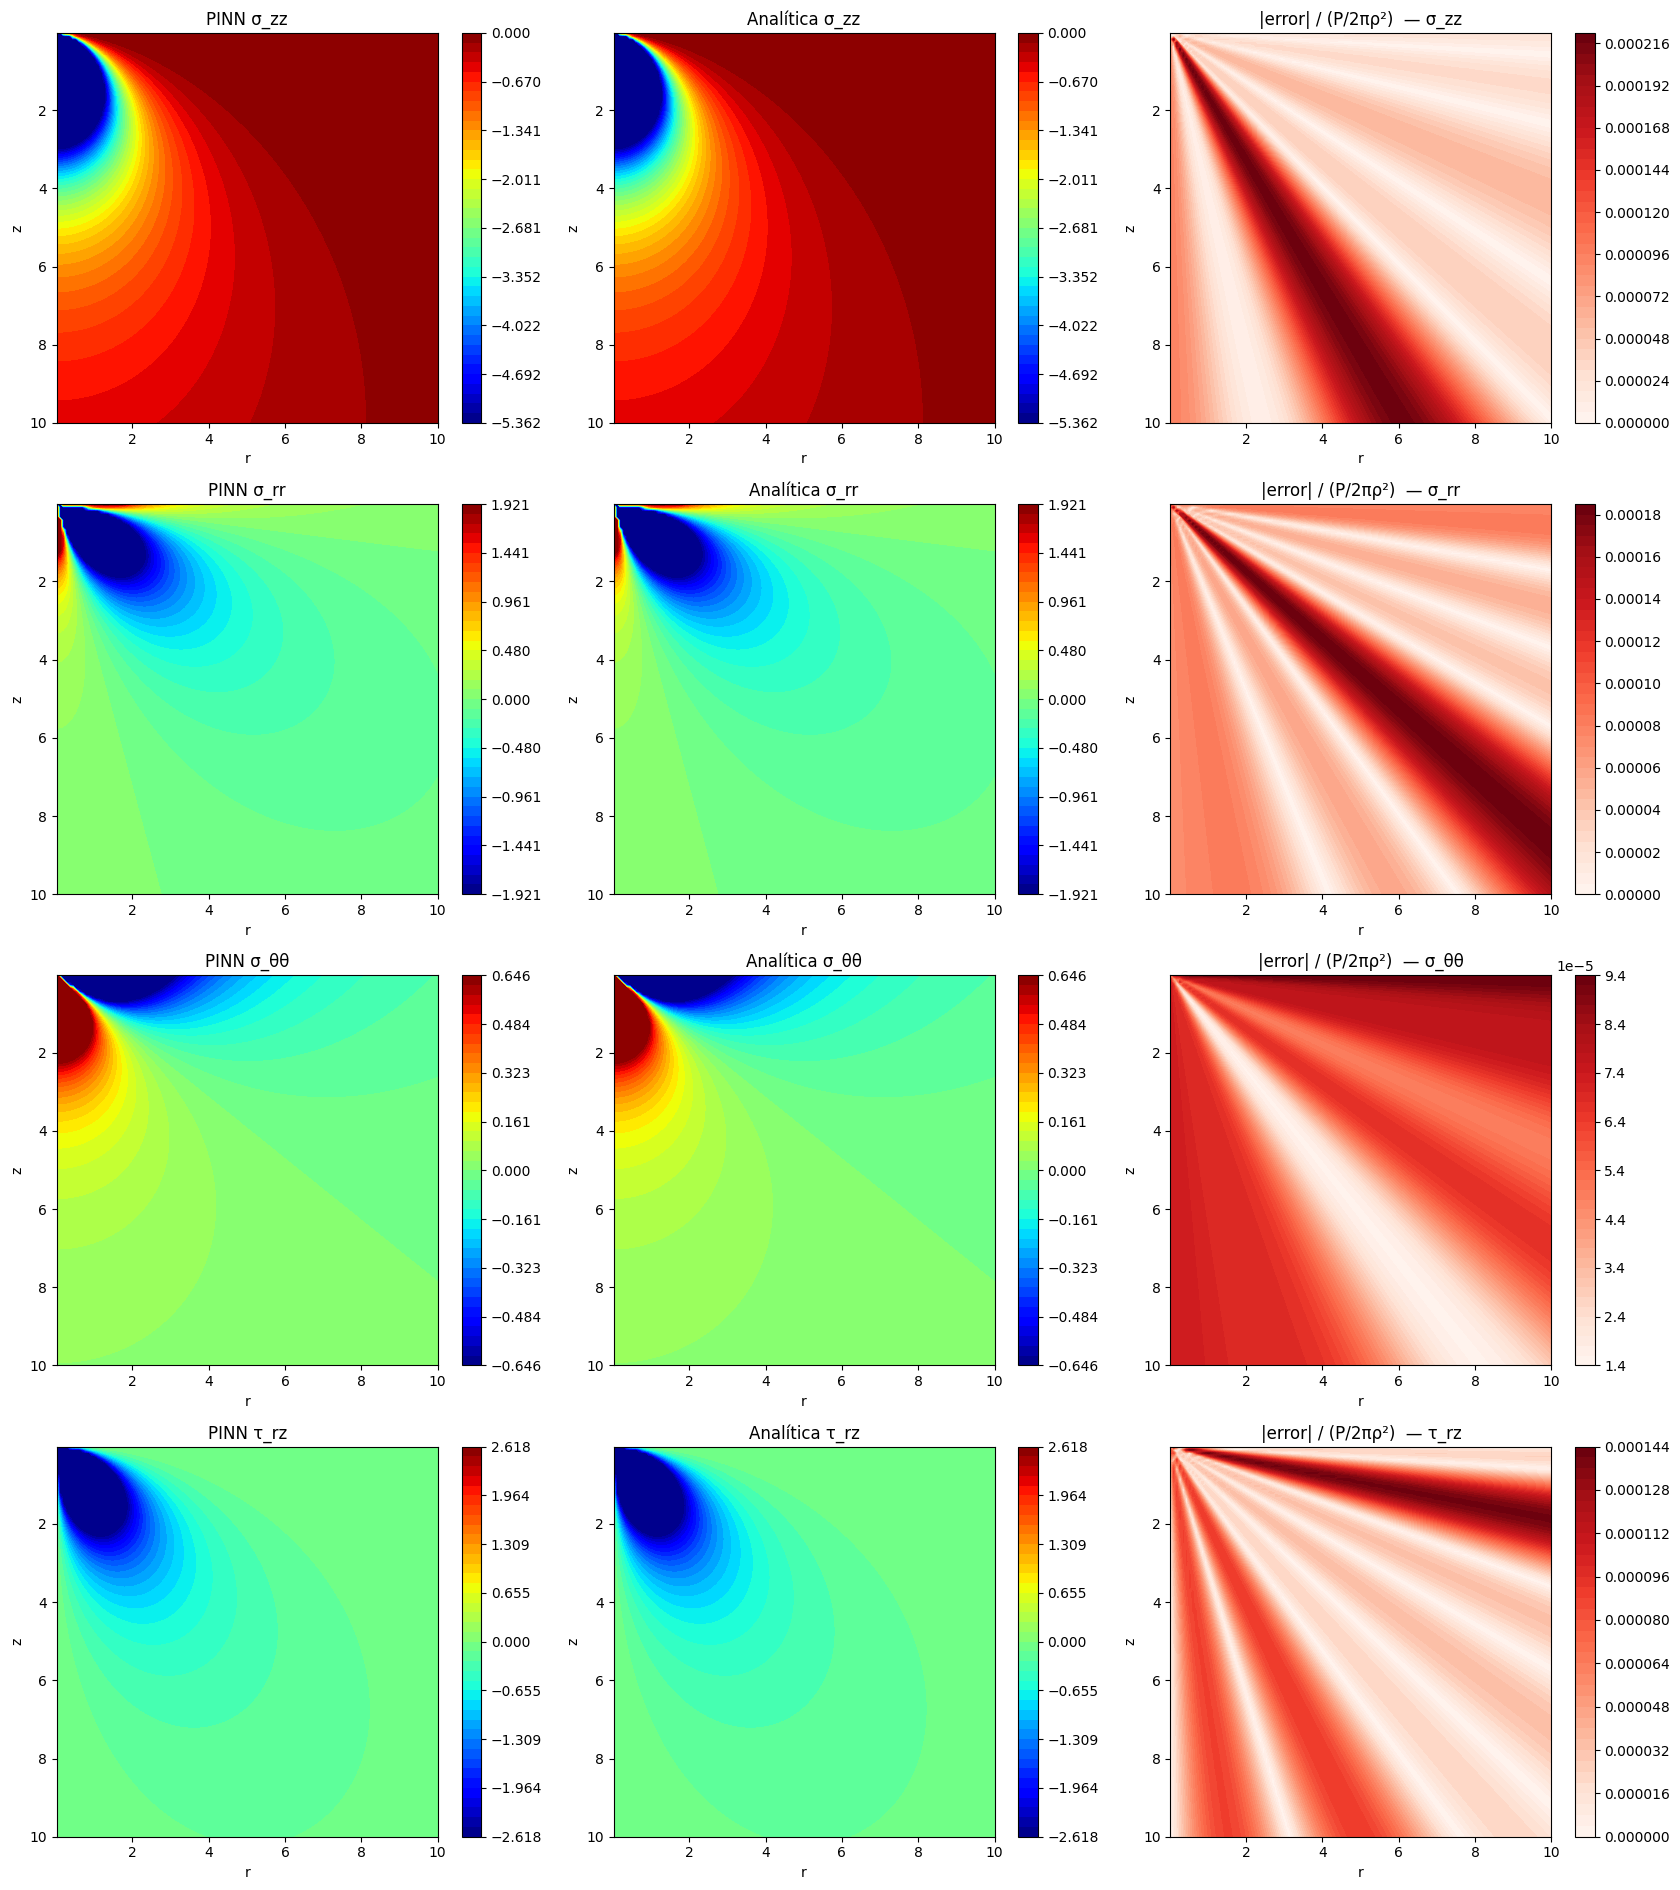

In [7]:
def to_t(a): return torch.tensor(a.reshape(-1, 1), device=device)

r = np.linspace(0.02, R_DOMAIN, 120); z = np.linspace(0.02, Z_DOMAIN, 120)
R, Z = np.meshgrid(r, z)
rt, zt = to_t(R), to_t(Z)
s_zz, s_rr, s_tt, t_rz = [v.detach().cpu().numpy().reshape(R.shape) for v in solver.get_stresses(rt, zt)]
u_r, w = [v.cpu().numpy().reshape(R.shape) for v in solver.displacements(rt, zt)]
pred = dict(s_zz=s_zz, s_rr=s_rr, s_tt=s_tt, t_rz=t_rz, u_r=u_r, w=w)
ref  = analytic(R, Z, P_LOAD, NU, E_MOD)

RHO = np.sqrt(R ** 2 + Z ** 2)
scale_s = P_LOAD / (2 * np.pi * RHO ** 2)                    # escala de tensión local
scale_u = P_LOAD / (2 * np.pi * E_MOD * RHO)                 # escala de desplazamiento local

names = dict(s_zz="σ_zz", s_rr="σ_rr", s_tt="σ_θθ", t_rz="τ_rz", u_r="u_r", w="w")
print(f"{'campo':>6} | {'error L2 relativo':>18} | {'error máx normalizado (local)':>30}")
for k in names:
    sc = scale_u if k in ("u_r", "w") else scale_s
    l2 = np.linalg.norm(pred[k] - ref[k]) / np.linalg.norm(ref[k])
    mx = np.max(np.abs(pred[k] - ref[k]) / sc)
    print(f"{names[k]:>6} | {l2:18.3e} | {mx:30.3e}")

fig, axes = plt.subplots(4, 3, figsize=(17, 19))
for row, k in zip(axes, ["s_zz", "s_rr", "s_tt", "t_rz"]):
    lim = np.percentile(np.abs(ref[k]), 97)
    lv = np.linspace(-lim, lim, 41) if k != "s_zz" else np.linspace(-lim, 0, 41)
    c1 = row[0].contourf(R, Z, np.clip(pred[k], lv[0], lv[-1]), levels=lv, cmap="jet"); plt.colorbar(c1, ax=row[0]); row[0].set_title(f"PINN {names[k]}")
    c2 = row[1].contourf(R, Z, np.clip(ref[k], lv[0], lv[-1]),  levels=lv, cmap="jet"); plt.colorbar(c2, ax=row[1]); row[1].set_title(f"Analítica {names[k]}")
    c3 = row[2].contourf(R, Z, np.abs(pred[k] - ref[k]) / scale_s, levels=40, cmap="Reds"); plt.colorbar(c3, ax=row[2]); row[2].set_title(f"|error| / (P/2πρ²)  — {names[k]}")
    for a in row: a.invert_yaxis(); a.set_xlabel("r"); a.set_ylabel("z")
plt.tight_layout(); plt.show()

### Comportamiento cerca de la singularidad

Se evalúa a lo largo de rayos que parten del origen desde ρ = 10⁻⁴ hasta 10 (**cinco décadas**). Si la red capturara la singularidad, ρ²·σ debe ser constante a lo largo de cada rayo y coincidir con la analítica.

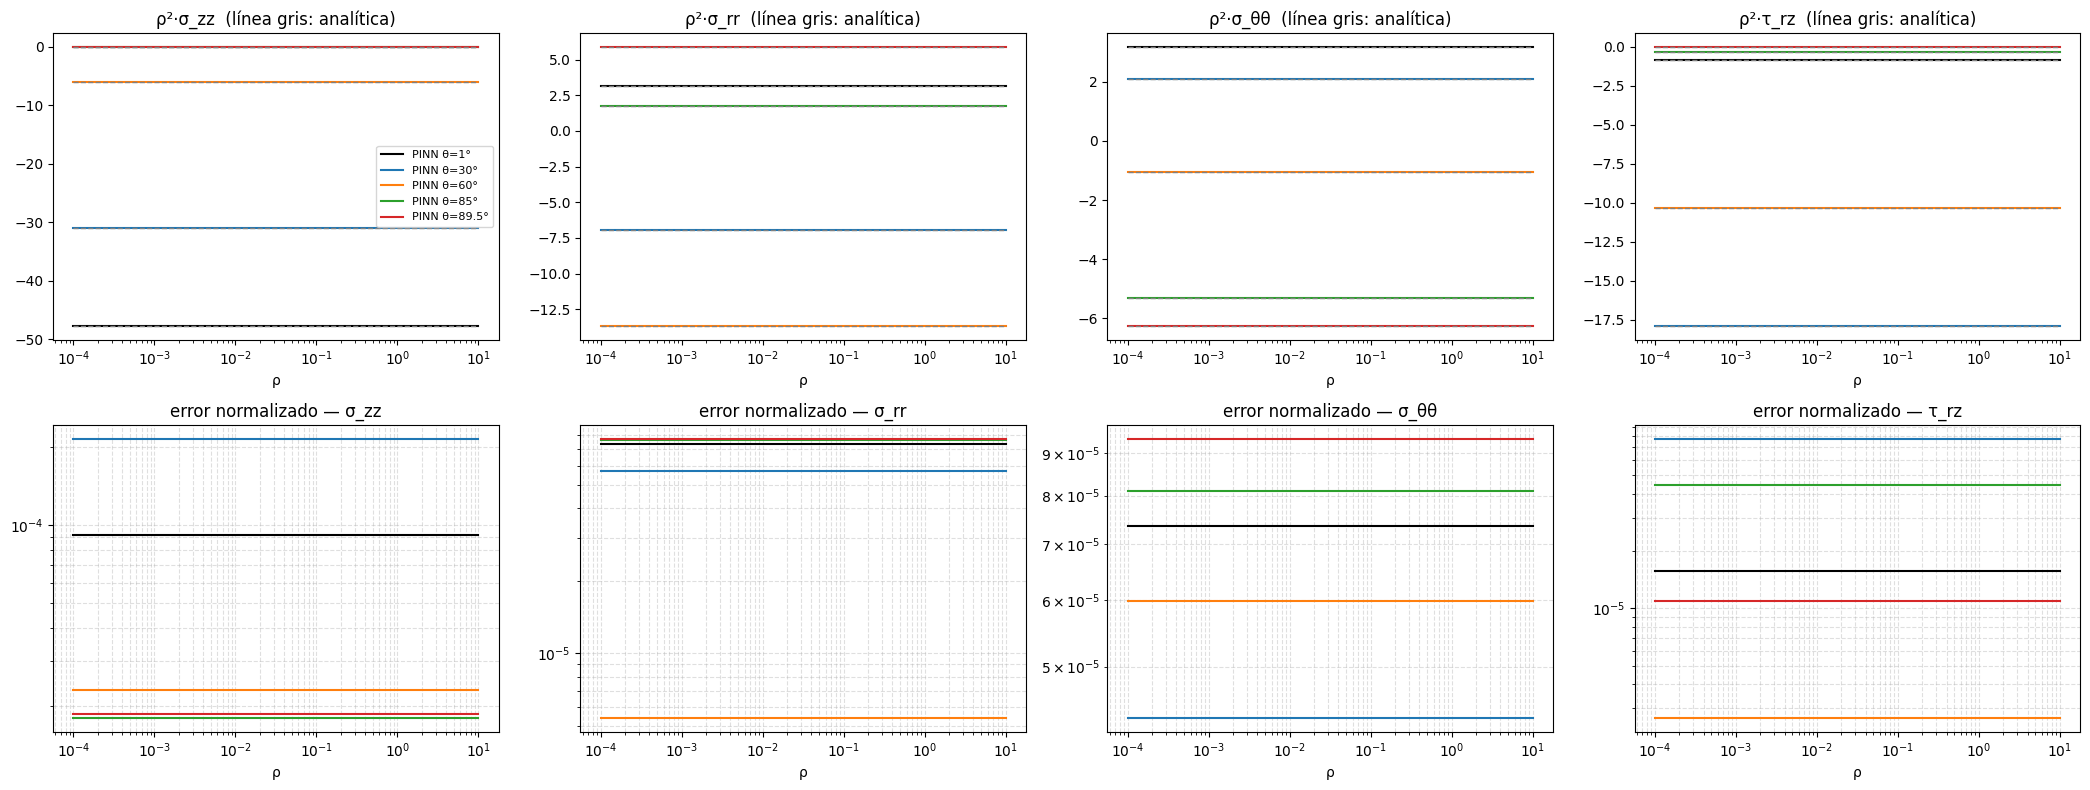


Fuerza vertical resultante sobre hemisferios de radio ρ₀ (esperado: -P = -100.0)
  ρ₀ =  1.00e-04  ->  F =   -99.999450
  ρ₀ =  5.18e-04  ->  F =   -99.999450
  ρ₀ =  2.68e-03  ->  F =   -99.999450
  ρ₀ =  1.39e-02  ->  F =   -99.999450
  ρ₀ =  7.20e-02  ->  F =   -99.999450
  ρ₀ =  3.73e-01  ->  F =   -99.999450
  ρ₀ =  1.93e+00  ->  F =   -99.999450
  ρ₀ =  1.00e+01  ->  F =   -99.999450


In [8]:
rho_line = np.logspace(-4, 1, 60)
fig, ax = plt.subplots(2, 4, figsize=(21, 8))
for th_deg, col in zip([1, 30, 60, 85, 89.5], ["k", "C0", "C1", "C2", "C3"]):
    th = np.deg2rad(th_deg)
    rl, zl = rho_line * np.sin(th), rho_line * np.cos(th)
    sp = [v.detach().cpu().numpy().ravel() for v in solver.get_stresses(to_t(rl), to_t(zl))]
    ra = analytic(rl, zl, P_LOAD, NU, E_MOD)
    for j, (k, i) in enumerate(zip(["s_zz", "s_rr", "s_tt", "t_rz"], range(4))):
        ax[0, j].semilogx(rho_line, sp[i] * rho_line ** 2, color=col, label=f"PINN θ={th_deg}°")
        ax[0, j].semilogx(rho_line, ra[k] * rho_line ** 2, "--", color="gray", lw=1)
        ax[1, j].loglog(rho_line, np.abs(sp[i] - ra[k]) / (P_LOAD / (2 * np.pi * rho_line ** 2)) + 1e-18, color=col)
for j, k in enumerate(["s_zz", "s_rr", "s_tt", "t_rz"]):
    ax[0, j].set_title(f"ρ²·{names[k]}  (línea gris: analítica)"); ax[0, j].set_xlabel("ρ")
    ax[1, j].set_title(f"error normalizado — {names[k]}"); ax[1, j].set_xlabel("ρ"); ax[1, j].grid(True, which="both", ls="--", alpha=.4)
ax[0, 0].legend(fontsize=8); plt.tight_layout(); plt.show()

# Equilibrio de la carga puntual: F(rho0) debe ser -P para cualquier hemisferio
rho0 = torch.tensor(np.logspace(-4, 1, 8), device=device)
F = (solver.force_residual(rho0) - 1.0).detach().cpu().numpy() * P_LOAD
print("\nFuerza vertical resultante sobre hemisferios de radio ρ₀ (esperado: -P = %.1f)" % -P_LOAD)
for a, b in zip(rho0.cpu().numpy(), F): print(f"  ρ₀ = {a:9.2e}  ->  F = {b:12.6f}")

> **Cómo leer el gráfico anterior.** Con `USE_S = False` las curvas ρ²·σ son *exactamente* planas por construcción: la red solo recibe cos θ, así que la autosemejanza está impuesta, no aprendida. Lo informativo aquí es que el nivel de cada curva coincide con la analítica (línea gris) y que el error se mantiene en 10⁻⁵–10⁻⁴ en las cinco décadas, incluso en ρ = 10⁻⁴, donde σ vale ~10⁸.
>
> Para una prueba más exigente, poner `USE_S = True` (la red recibe también ln ρ y debe descubrir la autosemejanza). En esa variante, con `hidden=40`, 1500 épocas de Adam y 3 rondas de L-BFGS, los errores L2 relativos medidos fueron: σ_zz 5.2·10⁻⁴, σ_rr 3.5·10⁻⁴, σ_θθ 1.3·10⁻³, τ_rz 3.6·10⁻⁴. Ahí las curvas ρ²·σ ya no son planas por construcción y la desviación respecto a la horizontal mide cuánto se aleja la red de la autosemejanza.

## 7. Desplazamientos

Además de las tensiones, se comparan los desplazamientos (que también divergen como 1/ρ en el origen).

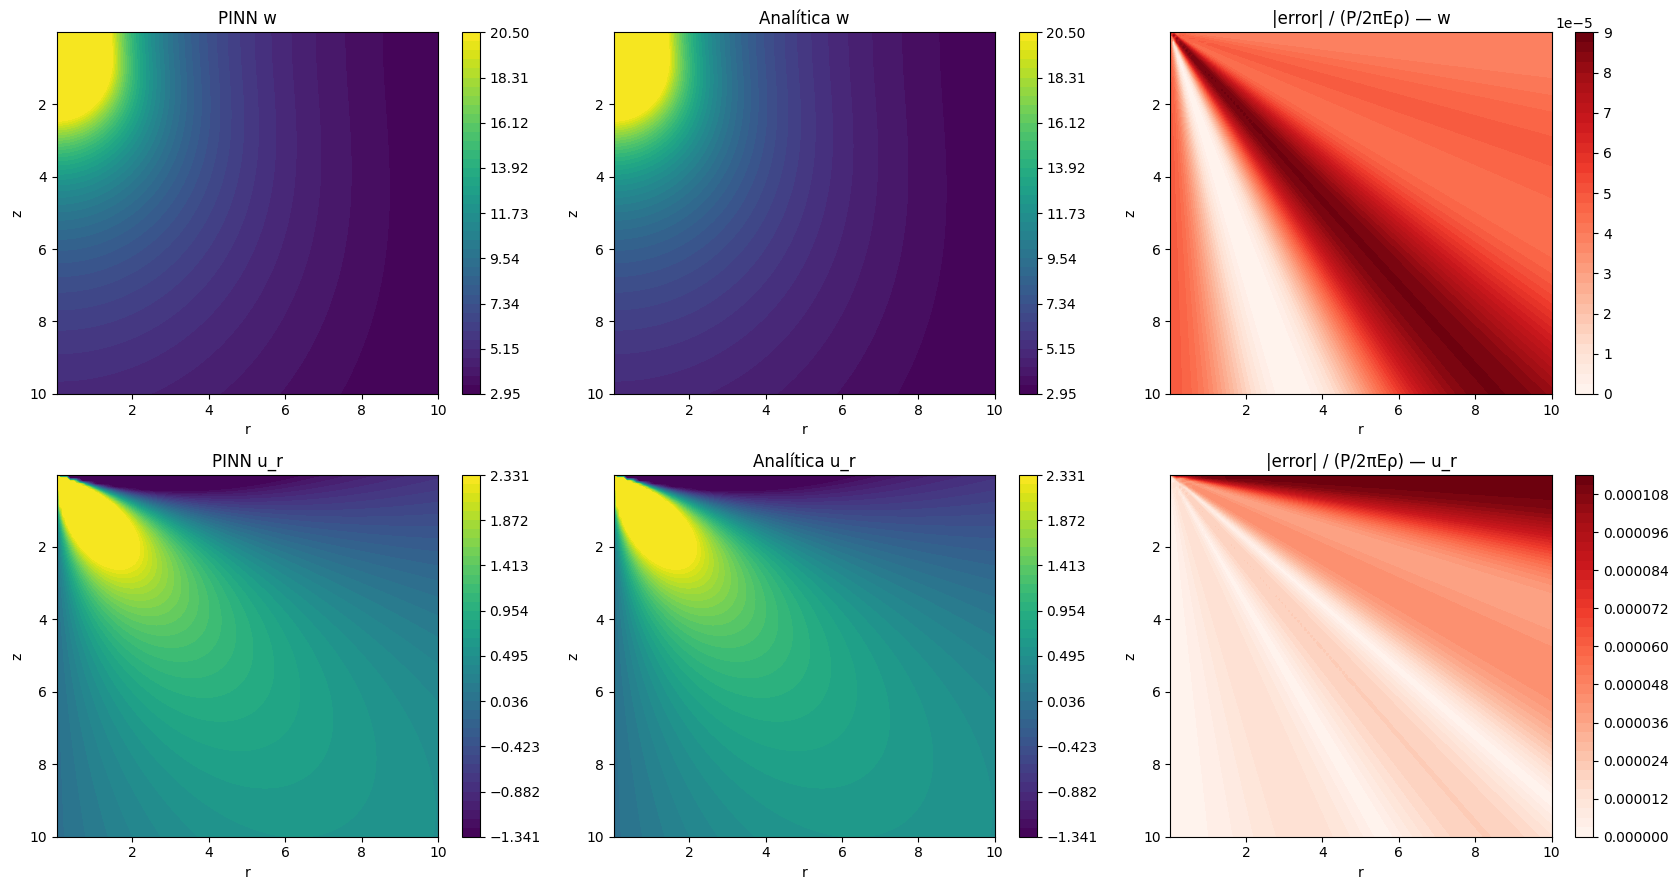

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for row, k in zip(axes, ["w", "u_r"]):
    lo, hi = np.percentile(ref[k], 2), np.percentile(ref[k], 97)
    lv = np.linspace(lo, hi, 41)
    c1 = row[0].contourf(R, Z, np.clip(pred[k], lv[0], lv[-1]), levels=lv, cmap="viridis"); plt.colorbar(c1, ax=row[0]); row[0].set_title(f"PINN {names[k]}")
    c2 = row[1].contourf(R, Z, np.clip(ref[k], lv[0], lv[-1]),  levels=lv, cmap="viridis"); plt.colorbar(c2, ax=row[1]); row[1].set_title(f"Analítica {names[k]}")
    c3 = row[2].contourf(R, Z, np.abs(pred[k] - ref[k]) / scale_u, levels=40, cmap="Reds"); plt.colorbar(c3, ax=row[2]); row[2].set_title(f"|error| / (P/2πEρ) — {names[k]}")
    for a in row: a.invert_yaxis(); a.set_xlabel("r"); a.set_ylabel("z")
plt.tight_layout(); plt.show()